# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

Metryki które będę stosować:

- accuracy - główna metryka, będzie dobra bo "Survived" nie jest ekstremalnie niezbalansowaną klasą

- F1-score — dodatkowa, bo bierze pod uwagę zarówno precision, jak i recall dla Survived = 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42


def evaluate_model(model, X_train, X_test, y_train, y_test):
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    scores = {
        "Train Accuracy": accuracy_score(y_train, train_predictions),
        "Test Accuracy": accuracy_score(y_test, test_predictions),
        "Train F1": f1_score(y_train, train_predictions),
        "Test F1": f1_score(y_test, test_predictions),
    }

    print("TRAIN")
    print("Accuracy:", scores["Train Accuracy"])
    print("F1:", scores["Train F1"])

    print("\nTEST")
    print("Accuracy:", scores["Test Accuracy"])
    print("F1:", scores["Test F1"])

    return scores

In [3]:
titanic_df = pd.read_csv('titanic_encoded.csv')

In [4]:
print(titanic_df.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'TicketGroupSize', 'FarePerPerson', 'HasCabin', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'TicketPrefix_CA', 'TicketPrefix_NONE', 'TicketPrefix_PC', 'TicketPrefix_Rare', 'TicketPrefix_SOTONOQ', 'TicketPrefix_STONO', 'TicketPrefix_WC', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsChild']


In [5]:
encoded_features = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
    'TicketGroupSize', 'FarePerPerson', 'HasCabin', 'FamilySize',
    'Embarked_Q', 'Embarked_S',
    'TicketPrefix_CA', 'TicketPrefix_NONE', 'TicketPrefix_PC',
    'TicketPrefix_Rare', 'TicketPrefix_SOTONOQ', 'TicketPrefix_STONO',
    'TicketPrefix_WC',
    'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F',
    'Deck_G', 'Deck_T', 'Deck_Unknown',
    'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
    'IsChild'
]

X = titanic_df[encoded_features]
y = titanic_df["Survived"]

Podzielmy dane na treningowe i testowe w stosunku 2:8. Porzucam ideę dzielenia danych na trzy części: 
TRAIN,
VALIDATION i
TEST. Boję się ze danych jest zbyt mało. Potem uzyję cross-validation

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

Dummy Classifier: nasz baseline. Przewiduje zawsze najczęściej występującą klasę.

In [7]:
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train, y_train)

dummy_scores = evaluate_model(dummy, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.6165730337078652
F1: 0.0

TEST
Accuracy: 0.6145251396648045
F1: 0.0


Dwa modele których uzyję to: XGBoost i Random Forest

Zacznijmy od randomforest

In [8]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

rf_scores = evaluate_model(rf, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.9929775280898876
F1: 0.990791896869245

TEST
Accuracy: 0.7653631284916201
F1: 0.6911764705882353


Duzy overfitting. Dobierzmy hiperparametry

uzywać będziemy 5 foldów:

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

Zacznijmy od n_estimators

In [10]:
rf_n_estimators_values = [10, 25, 50, 100, 200, 500]

In [11]:
rf_estimators_results = []

for n_estimators in rf_n_estimators_values:
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE
    )

    accuracy_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    f1_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    rf_estimators_results.append({
        "n_estimators": n_estimators,
        "accuracy": accuracy_scores.mean(),
        "f1": f1_scores.mean()
    })

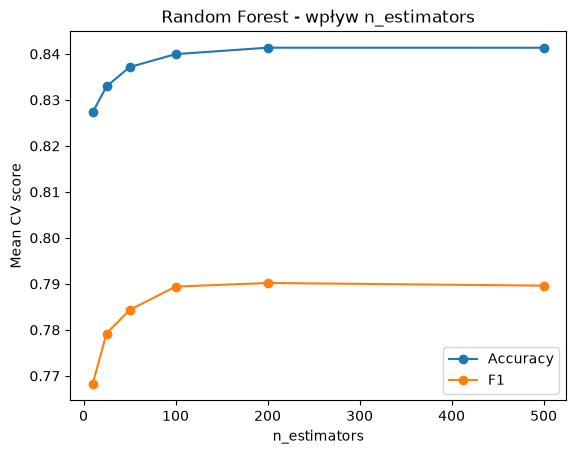

In [12]:
rf_estimators_df = pd.DataFrame(rf_estimators_results)

plt.plot(
    rf_estimators_df["n_estimators"],
    rf_estimators_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_estimators_df["n_estimators"],
    rf_estimators_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("n_estimators")
plt.ylabel("Mean CV score")
plt.title("Random Forest - wpływ n_estimators")
plt.legend()
plt.show()

Teraz zbadajmy max_depth

In [13]:
max_depth_values = [2, 3, 4, 5, 6, 8, 10, 15, None]

rf_depth_results = []

for max_depth in max_depth_values:
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=max_depth,
        random_state=RANDOM_STATE
    )

    accuracy_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    f1_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    rf_depth_results.append({
        "max_depth": str(max_depth),
        "accuracy": accuracy_scores.mean(),
        "f1": f1_scores.mean()
    })

In [14]:
rf_depth_df = pd.DataFrame(rf_depth_results)

rf_depth_df

,max_depth,accuracy,f1
0,2,0.807574,0.722271
1,3,0.823077,0.754858
2,4,0.824476,0.759964
3,5,0.824505,0.761240
4,6,0.824505,0.759510
5,8,0.828721,0.766715
6,10,0.838550,0.779787
7,15,0.834345,0.778970
8,None,0.841347,0.790194


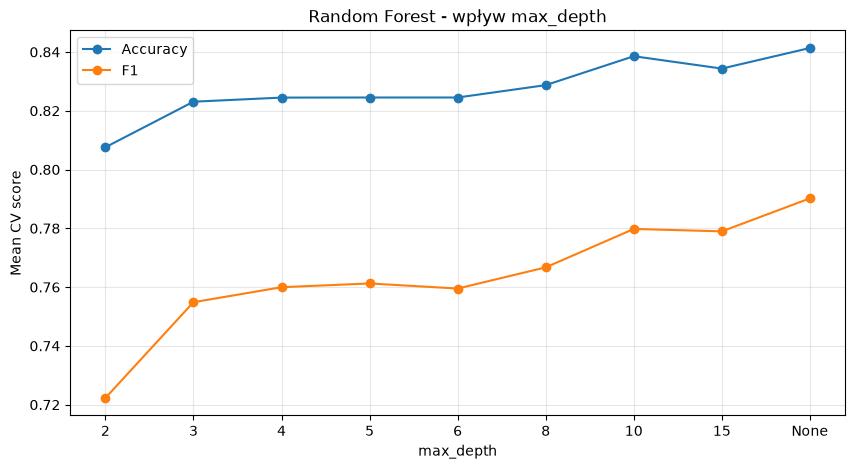

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    rf_depth_df["max_depth"],
    rf_depth_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_depth_df["max_depth"],
    rf_depth_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("max_depth")
plt.ylabel("Mean CV score")
plt.title("Random Forest - wpływ max_depth")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Znajdźmy najlepsze wartości:

In [16]:
best_depth_accuracy = rf_depth_df.loc[
    rf_depth_df["accuracy"].idxmax()
]

best_depth_f1 = rf_depth_df.loc[
    rf_depth_df["f1"].idxmax()
]

print("Best by Accuracy:")
print(best_depth_accuracy)

print("\nBest by F1:")
print(best_depth_f1)

Best by Accuracy:
max_depth        None
accuracy     0.841347
f1           0.790194
Name: 8, dtype: object

Best by F1:
max_depth        None
accuracy     0.841347
f1           0.790194
Name: 8, dtype: object


Ale przeciez kombinacje parametrów mogą mieć rózne wyniki. Uzyjmy do tego GridSearchCV

In [17]:
rf_basic_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [4, 5, 6, 7, 8, 10, None]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_basic_param_grid,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

best_f1_accuracy = rf_grid.cv_results_['mean_test_f1'][rf_grid.best_index_]

print("Best parameters (optimized for Accuracy):")
print(rf_grid.best_params_)
print(f"\nBest CV Accuracy: {rf_grid.best_score_:.6f}")
print(f"Best CV F1-score: {best_f1_accuracy:.6f}")

Best parameters (optimized for Accuracy):
{'max_depth': None, 'n_estimators': 300}

Best CV Accuracy: 0.842746
Best CV F1-score: 0.791793


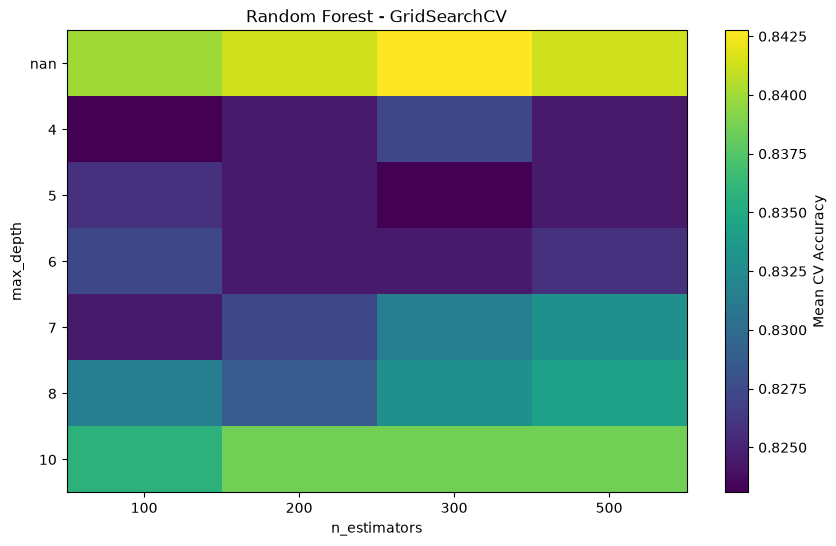

In [18]:
grid_results = pd.DataFrame(rf_grid.cv_results_)

pivot = grid_results.pivot(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_accuracy"
)

plt.figure(figsize=(10, 6))

plt.imshow(
    pivot,
    aspect="auto"
)

plt.colorbar(label="Mean CV Accuracy")

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.title("Random Forest - GridSearchCV")

plt.show()

In [19]:
best_rf = rf_grid.best_estimator_

In [20]:
rf_grid_scores = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.9929775280898876
F1: 0.990791896869245

TEST
Accuracy: 0.7877094972067039
F1: 0.7205882352941176


uuu, overfitting?
max_depth=None pozwoliło drzewom być za bardzo złozonymi?
albo test split ma cięzsze przykłady?

Spróbujmy z większą liczbą hiperparametrów

In [21]:
rf_extended_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

In [22]:
rf_grid_2 = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_extended_param_grid,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_2.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid_2.best_params_)

print("\nBest CV Accuracy:")
print(rf_grid_2.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Accuracy:
0.8427459864079582


In [23]:
best_rf_2 = rf_grid_2.best_estimator_

best_rf_2_scores = evaluate_model(best_rf_2, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.9929775280898876
F1: 0.990791896869245

TEST
Accuracy: 0.7877094972067039
F1: 0.7205882352941176


Te same wyniki :\

In [24]:
results = pd.DataFrame(rf_grid_2.cv_results_)
results[[
    "param_max_depth",
    "param_min_samples_leaf",
    "param_min_samples_split",
    "param_n_estimators",
    "mean_train_accuracy",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_train_f1",
    "mean_test_f1",
    "std_test_f1"
]].sort_values(
    "mean_test_accuracy",
    ascending=False
).head(15)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
241,None,1,2,300,0.993679,0.842746,0.016483,0.991743,0.791793,0.022184
240,None,1,2,200,0.993679,0.841347,0.018660,0.991743,0.790194,0.026214
242,None,1,2,500,0.993679,0.841338,0.014613,0.991735,0.789618,0.019069
196,10,1,5,300,0.929078,0.839949,0.026399,0.902980,0.782773,0.033665
193,10,1,2,300,0.955059,0.838560,0.035433,0.938807,0.780896,0.048435
194,10,1,2,500,0.957517,0.838550,0.033461,0.942291,0.780159,0.045483
192,10,1,2,200,0.953654,0.838550,0.033197,0.936761,0.779787,0.046715
244,None,1,5,300,0.949440,0.838521,0.020504,0.932324,0.780169,0.027506
195,10,1,5,200,0.929077,0.837152,0.029799,0.903159,0.779522,0.039643
197,10,1,5,500,0.928726,0.835733,0.028623,0.902643,0.775566,0.038056


Zatem najlepsze parametry:
- n_estimators       = 300
- max_depth           = None
- min_samples_split   = 2
- min_samples_leaf    = 1

5-fold CV:
- Accuracy = 84.27%
- F1       = 79.18%
- std Acc  = 1.65 p.p.

Train:
- Accuracy = 99.30%
- F1       = 99.08%

Test:
- Accuracy = 78.77%
- F1       = 72.06%

Zajmijmy się teraz XGBoostem

In [25]:
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_scores = evaluate_model(xgb, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.9859550561797753
F1: 0.9816176470588235

TEST
Accuracy: 0.7821229050279329
F1: 0.7153284671532847


Zacznijmy teraz dostrajać dwa najwazniejsze hiperparametry: max_depth i learning_rate

In [26]:
xgb_depth_results = []

for max_depth in [1, 2, 3, 4, 5, 6, 8]:
    xgb_model = XGBClassifier(
        max_depth=max_depth,
        learning_rate=0.1,
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    scores = cross_validate(
        xgb_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1"
        },
        return_train_score=True
    )

    xgb_depth_results.append({
        "max_depth": max_depth,
        "mean_train_accuracy": scores["train_accuracy"].mean(),
        "mean_test_accuracy": scores["test_accuracy"].mean(),
        "std_test_accuracy": scores["test_accuracy"].std(),
        "mean_train_f1": scores["train_f1"].mean(),
        "mean_test_f1": scores["test_f1"].mean(),
        "std_test_f1": scores["test_f1"].std()
    })

xgb_depth_df = pd.DataFrame(xgb_depth_results)

xgb_depth_df

,max_depth,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
0,1,0.838134,0.807623,0.028073,0.782589,0.744175,0.035519
1,2,0.868329,0.806185,0.030989,0.821123,0.739480,0.031380
2,3,0.908714,0.811849,0.031851,0.874839,0.745208,0.036625
3,4,0.932236,0.832946,0.030094,0.908330,0.774446,0.039252
4,5,0.942419,0.824485,0.024754,0.922119,0.763105,0.031323
5,6,0.955059,0.823087,0.025236,0.939591,0.760481,0.034169
6,8,0.972262,0.821668,0.025791,0.963137,0.756201,0.035845


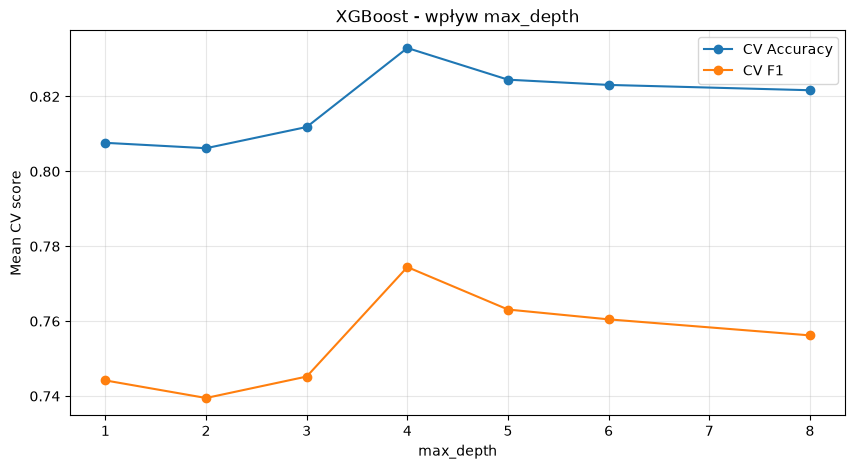

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_depth_df["max_depth"],
    xgb_depth_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.plot(
    xgb_depth_df["max_depth"],
    xgb_depth_df["mean_test_f1"],
    marker="o",
    label="CV F1"
)

plt.xlabel("max_depth")
plt.ylabel("Mean CV score")
plt.title("XGBoost - wpływ max_depth")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

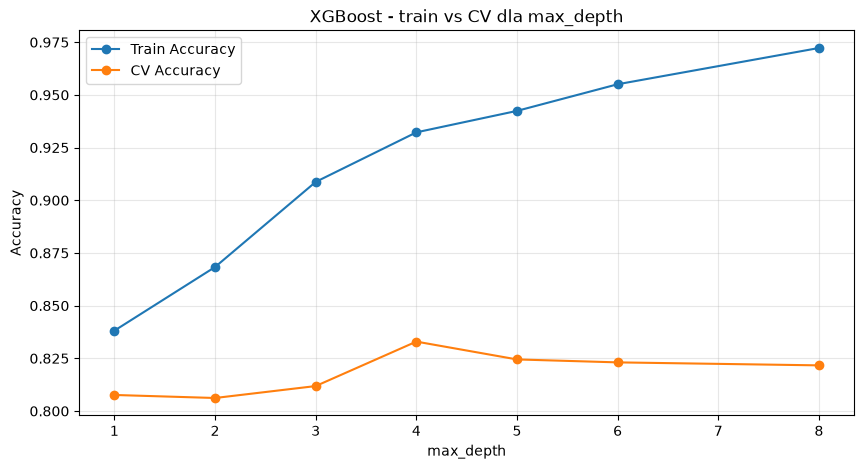

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_depth_df["max_depth"],
    xgb_depth_df["mean_train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    xgb_depth_df["max_depth"],
    xgb_depth_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("XGBoost - train vs CV dla max_depth")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

max_depth 4 wygląda najlepiej, potem overfitting, gorsza generalizacja

In [29]:
learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]

xgb_lr_results = []

for learning_rate in learning_rates:
    xgb_model = XGBClassifier(
        max_depth=4,
        learning_rate=learning_rate,
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    scores = cross_validate(
        xgb_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1"
        },
        return_train_score=True
    )

    xgb_lr_results.append({
        "learning_rate": learning_rate,
        "mean_train_accuracy": scores["train_accuracy"].mean(),
        "mean_test_accuracy": scores["test_accuracy"].mean(),
        "std_test_accuracy": scores["test_accuracy"].std(),
        "mean_train_f1": scores["train_f1"].mean(),
        "mean_test_f1": scores["test_f1"].mean(),
        "std_test_f1": scores["test_f1"].std()
    })

xgb_lr_df = pd.DataFrame(xgb_lr_results)

xgb_lr_df

,learning_rate,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
0,0.01,0.867276,0.828671,0.014221,0.810976,0.753621,0.024656
1,0.03,0.890803,0.823067,0.020223,0.847854,0.752183,0.025768
2,0.05,0.906955,0.825884,0.023763,0.871926,0.759799,0.031815
3,0.10,0.932236,0.832946,0.030094,0.908330,0.774446,0.039252
4,0.20,0.953655,0.825894,0.021916,0.938204,0.767223,0.026644
5,0.30,0.967698,0.818861,0.023710,0.956870,0.757567,0.026645


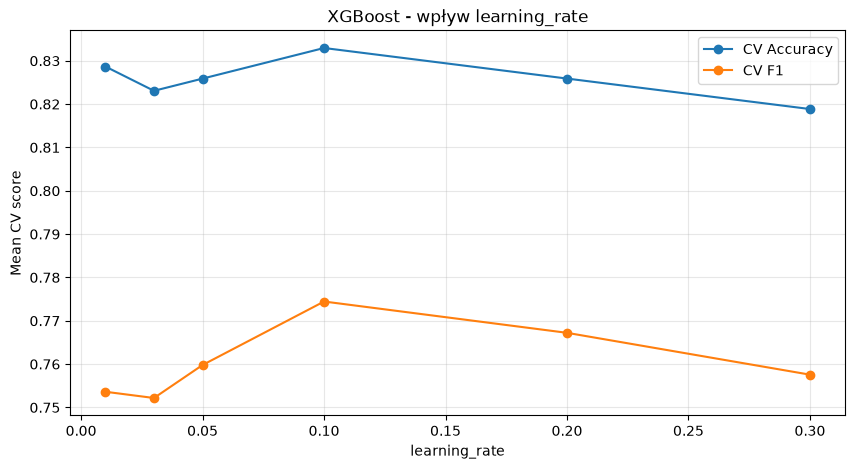

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_lr_df["learning_rate"],
    xgb_lr_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.plot(
    xgb_lr_df["learning_rate"],
    xgb_lr_df["mean_test_f1"],
    marker="o",
    label="CV F1"
)

plt.xlabel("learning_rate")
plt.ylabel("Mean CV score")
plt.title("XGBoost - wpływ learning_rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

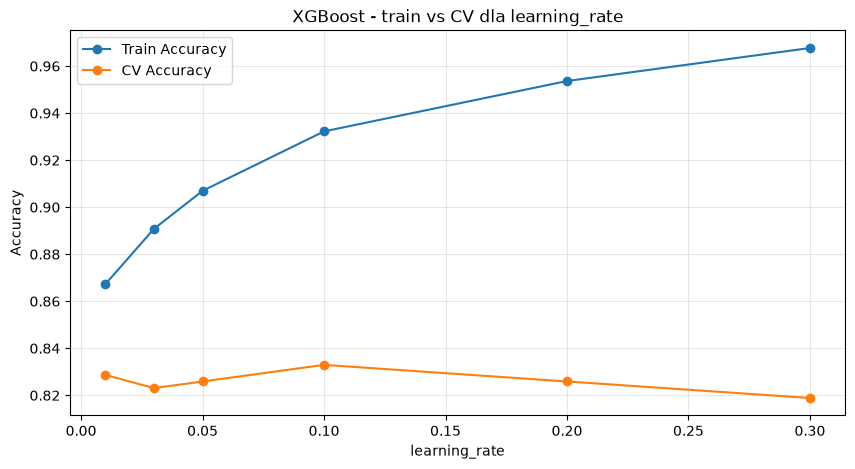

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_lr_df["learning_rate"],
    xgb_lr_df["mean_train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    xgb_lr_df["learning_rate"],
    xgb_lr_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("XGBoost - train vs CV dla learning_rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

learning_rate = 0.1 wygląda najlepiej, potem overfitting

sprawdźmy n_estimators

In [32]:
xgb_n_estimators_values = [25, 50, 100, 150, 200, 300, 500]

xgb_estimators_results = []

for n_estimators in xgb_n_estimators_values:
    xgb_model = XGBClassifier(
        max_depth=4,
        learning_rate=0.1,
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    scores = cross_validate(
        xgb_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1"
        },
        return_train_score=True
    )

    xgb_estimators_results.append({
        "n_estimators": n_estimators,
        "mean_train_accuracy": scores["train_accuracy"].mean(),
        "mean_test_accuracy": scores["test_accuracy"].mean(),
        "std_test_accuracy": scores["test_accuracy"].std(),
        "mean_train_f1": scores["train_f1"].mean(),
        "mean_test_f1": scores["test_f1"].mean(),
        "std_test_f1": scores["test_f1"].std()
    })

xgb_estimators_df = pd.DataFrame(xgb_estimators_results)

xgb_estimators_df

,n_estimators,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
0,25,0.885188,0.825894,0.027492,0.841585,0.759154,0.034950
1,50,0.908009,0.825864,0.029798,0.873233,0.760414,0.035910
2,100,0.932236,0.832946,0.030094,0.908330,0.774446,0.039252
3,150,0.939958,0.831518,0.022195,0.919093,0.772934,0.028666
4,200,0.948386,0.827292,0.017625,0.930799,0.765934,0.021487
5,300,0.963836,0.820260,0.023450,0.951617,0.757120,0.027398
6,500,0.981038,0.816025,0.016098,0.974957,0.752583,0.017259


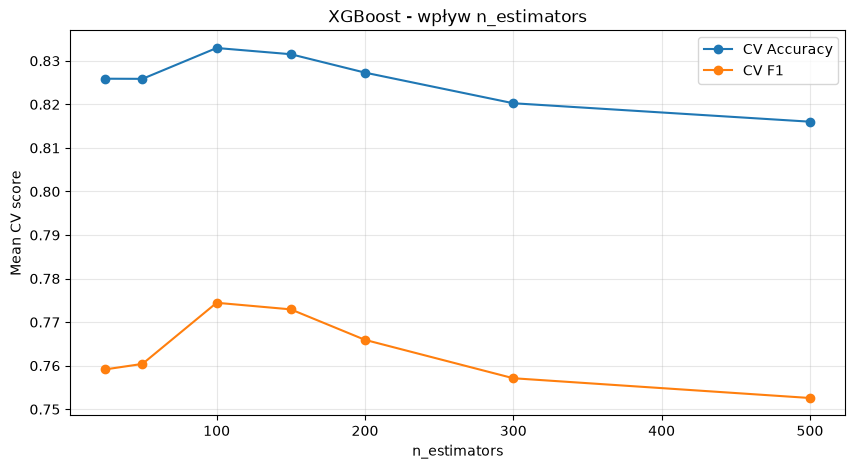

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_estimators_df["n_estimators"],
    xgb_estimators_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.plot(
    xgb_estimators_df["n_estimators"],
    xgb_estimators_df["mean_test_f1"],
    marker="o",
    label="CV F1"
)

plt.xlabel("n_estimators")
plt.ylabel("Mean CV score")
plt.title("XGBoost - wpływ n_estimators")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

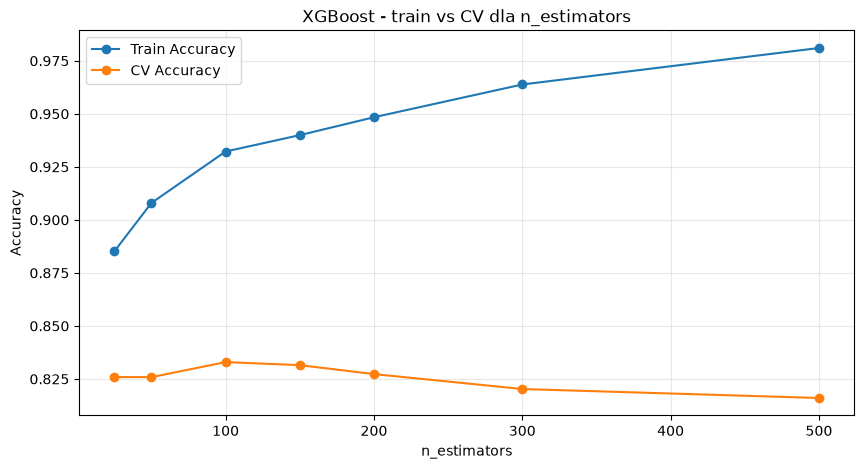

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    xgb_estimators_df["n_estimators"],
    xgb_estimators_df["mean_train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    xgb_estimators_df["n_estimators"],
    xgb_estimators_df["mean_test_accuracy"],
    marker="o",
    label="CV Accuracy"
)

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("XGBoost - train vs CV dla n_estimators")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

to samo, overfitting. Najlepsza wartość to 100

uzyjmy tez gridsearch

In [35]:
xgb_param_grid = {
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 150, 200, 300, 500]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ),
    param_grid=xgb_param_grid,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)

print("\nBest CV Accuracy:")
print(xgb_grid.best_score_)

Best parameters:
{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}

Best CV Accuracy:
0.8343149807938539


In [36]:
xgb_grid_results = pd.DataFrame(xgb_grid.cv_results_)

xgb_grid_results[[
    "param_max_depth",
    "param_learning_rate",
    "param_n_estimators",
    "mean_train_accuracy",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_train_f1",
    "mean_test_f1",
    "std_test_f1"
]].sort_values(
    "mean_test_accuracy",
    ascending=False
).head(15)

,param_max_depth,param_learning_rate,param_n_estimators,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
81,5,0.05,200,0.943121,0.834315,0.025788,0.923328,0.775889,0.033435
25,6,0.01,100,0.893612,0.834315,0.030614,0.849421,0.759996,0.045335
103,4,0.10,100,0.932236,0.832946,0.030094,0.908330,0.774446,0.039252
99,3,0.10,200,0.928726,0.832926,0.027452,0.903428,0.776170,0.034366
76,4,0.05,300,0.942066,0.832916,0.020084,0.922067,0.774514,0.024572
47,4,0.03,500,0.940662,0.831528,0.026195,0.920137,0.773129,0.032864
75,4,0.05,200,0.933991,0.831518,0.023041,0.910290,0.771207,0.029657
100,3,0.10,300,0.942771,0.831518,0.024664,0.923128,0.773079,0.030089
104,4,0.10,150,0.939958,0.831518,0.022195,0.919093,0.772934,0.028666
139,5,0.20,100,0.970158,0.830109,0.020526,0.960318,0.771268,0.027068


Najlepszy XG_Boost:

- max_depth = 5
- learning_rate = 0.05
- n_estimators = 200

- CV Accuracy = 0.834315
- CV F1       = 0.775889

Porównajmy go jeszcze na zbiorze treningowym i testowym.

In [37]:
best_xgb = XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

best_xgb.fit(X_train, y_train)

best_xgb_scores = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

TRAIN
Accuracy: 0.9353932584269663
F1: 0.9128787878787878

TEST
Accuracy: 0.8212290502793296
F1: 0.7611940298507462


Na końcu porównajmy najlepsze wersje modeli na tych samych metrykach.

PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI

           Model  Train Accuracy  Test Accuracy  Train F1  Test F1
Dummy Classifier        0.616573       0.614525  0.000000 0.000000
   Random Forest        0.992978       0.787709  0.990792 0.720588
         XGBoost        0.935393       0.821229  0.912879 0.761194


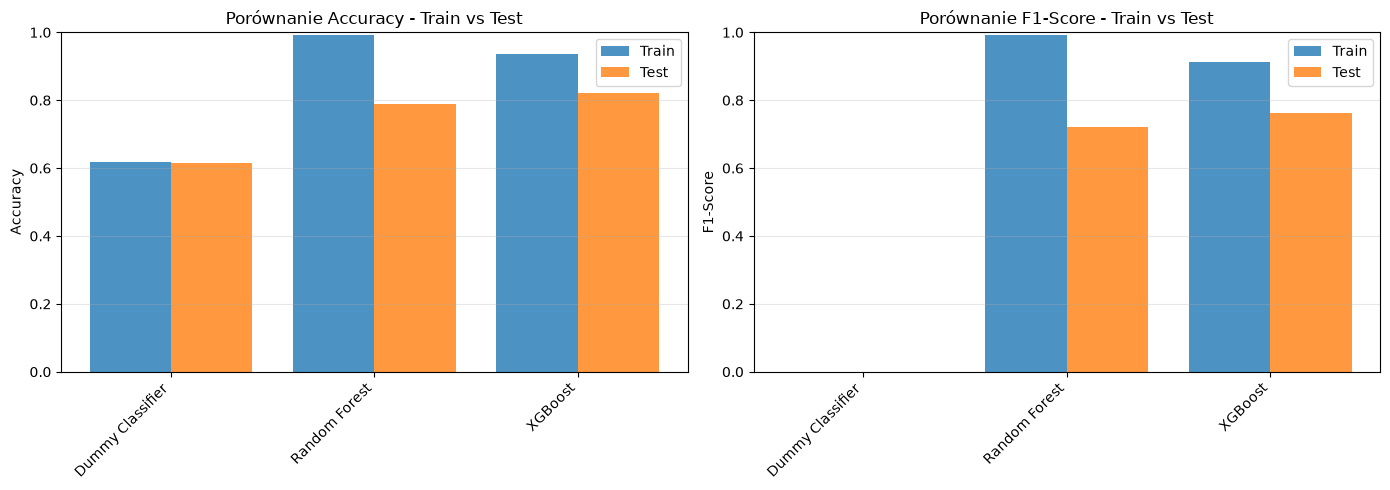

In [38]:
# Porównanie wyników najlepszych modeli
model_scores = {
    "Dummy Classifier": dummy_scores,
    "Random Forest": best_rf_2_scores,
    "XGBoost": best_xgb_scores,
}

comparison_df = pd.DataFrame([
    {"Model": model_name, **scores}
    for model_name, scores in model_scores.items()
])

print("=" * 80)
print("PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI")
print("=" * 80)
print("\n" + comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = range(len(comparison_df))

axes[0].bar(
    [i - 0.2 for i in x_pos],
    comparison_df["Train Accuracy"],
    width=0.4,
    label="Train",
    alpha=0.8
)
axes[0].bar(
    [i + 0.2 for i in x_pos],
    comparison_df["Test Accuracy"],
    width=0.4,
    label="Test",
    alpha=0.8
)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Porównanie Accuracy - Train vs Test")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df["Model"], rotation=45, ha="right")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].bar(
    [i - 0.2 for i in x_pos],
    comparison_df["Train F1"],
    width=0.4,
    label="Train",
    alpha=0.8
)
axes[1].bar(
    [i + 0.2 for i in x_pos],
    comparison_df["Test F1"],
    width=0.4,
    label="Test",
    alpha=0.8
)
axes[1].set_ylabel("F1-Score")
axes[1].set_title("Porównanie F1-Score - Train vs Test")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df["Model"], rotation=45, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

Ale moze da się polepszyć mój model?

wziąłem do szkolenia bardzo róznych cech, moze za duzo?

In [39]:
feature_sets = {
    "All features": X_train.columns.tolist(),

    "Without SibSp/Parch": [
        col for col in X_train.columns
        if col not in ["SibSp", "Parch"]
    ],

    "Without HasCabin": [
        col for col in X_train.columns
        if col != "HasCabin"
    ],

    "Without Fare": [
        col for col in X_train.columns
        if col != "Fare"
    ],

    "Without FarePerPerson": [
        col for col in X_train.columns
        if col != "FarePerPerson"
    ],

    "Without IsChild": [
        col for col in X_train.columns
        if col != "IsChild"
    ],

    "Without TicketPrefix": [
        col for col in X_train.columns
        if not col.startswith("TicketPrefix_")
    ],

    "Without Deck": [
        col for col in X_train.columns
        if not col.startswith("Deck_")
    ],

    "Without Title": [
        col for col in X_train.columns
        if not col.startswith("Title_")
    ],
}

In [40]:
feature_results = []

for name, features in feature_sets.items():

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
    )

    scores = cross_validate(
        model,
        X_train[features],
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
    )

    feature_results.append({
        "Feature set": name,
        "Number of features": len(features),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "STD Accuracy": scores["test_accuracy"].std(),
        "CV F1": scores["test_f1"].mean(),
        "STD F1": scores["test_f1"].std(),
    })

In [41]:
feature_results_df = pd.DataFrame(feature_results)

feature_results_df = feature_results_df.sort_values(
    "CV Accuracy",
    ascending=False,
)

feature_results_df

,Feature set,Number of features,CV Accuracy,STD Accuracy,CV F1,STD F1
0,All features,32,0.842746,0.016483,0.791793,0.022184
5,Without IsChild,31,0.839919,0.009790,0.787263,0.014129
2,Without HasCabin,31,0.838540,0.019371,0.785713,0.026727
7,Without Deck,24,0.838521,0.022825,0.785443,0.032608
3,Without Fare,31,0.831508,0.015469,0.774967,0.023943
4,Without FarePerPerson,31,0.831478,0.015132,0.774185,0.022584
1,Without SibSp/Parch,30,0.830119,0.025579,0.773965,0.033826
8,Without Title,28,0.827273,0.017313,0.775247,0.019069
6,Without TicketPrefix,25,0.823087,0.023229,0.764768,0.032302


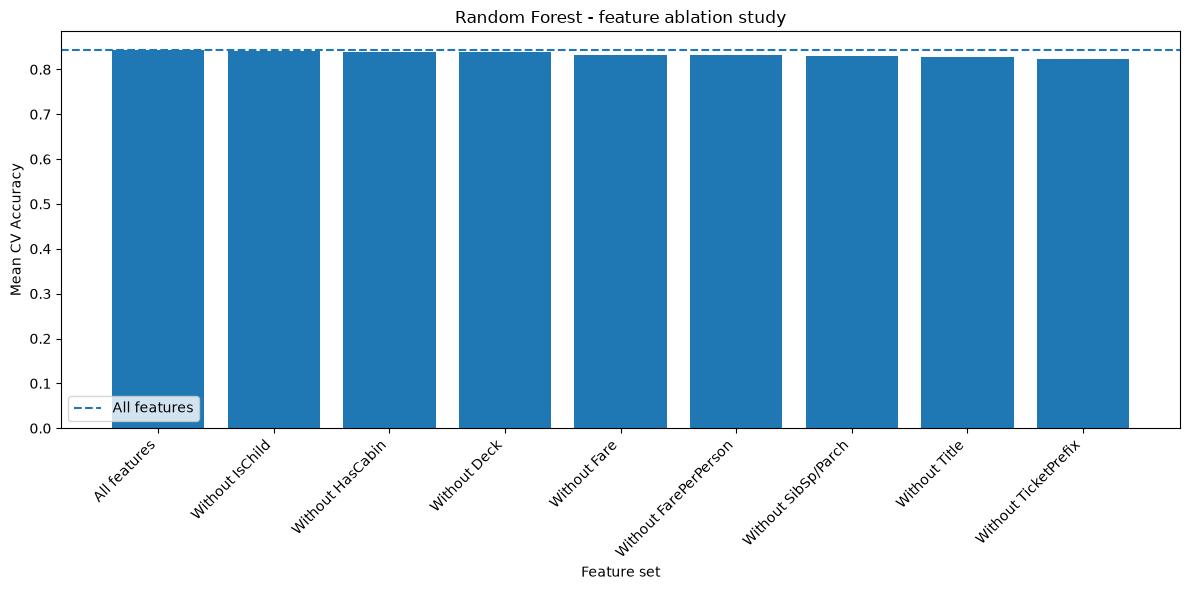

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    feature_results_df["Feature set"],
    feature_results_df["CV Accuracy"],
)

plt.axhline(
    y=feature_results_df.loc[
        feature_results_df["Feature set"] == "All features",
        "CV Accuracy"
    ].iloc[0],
    linestyle="--",
    label="All features",
)

plt.ylabel("Mean CV Accuracy")
plt.xlabel("Feature set")
plt.title("Random Forest - feature ablation study")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
xgb_feature_results = []

for name, features in feature_sets.items():

    model = XGBClassifier(
        max_depth=5,
        learning_rate=0.05,
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )

    scores = cross_validate(
        model,
        X_train[features],
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
    )

    xgb_feature_results.append({
        "Feature set": name,
        "Number of features": len(features),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "STD Accuracy": scores["test_accuracy"].std(),
        "CV F1": scores["test_f1"].mean(),
        "STD F1": scores["test_f1"].std(),
    })

In [44]:
xgb_feature_results_df = pd.DataFrame(xgb_feature_results)

xgb_feature_results_df = xgb_feature_results_df.sort_values(
    "CV Accuracy",
    ascending=False,
)

xgb_feature_results_df

,Feature set,Number of features,CV Accuracy,STD Accuracy,CV F1,STD F1
0,All features,32,0.834315,0.025788,0.775889,0.033435
5,Without IsChild,31,0.834315,0.025788,0.775889,0.033435
2,Without HasCabin,31,0.832907,0.026499,0.773613,0.034095
3,Without Fare,31,0.831528,0.031930,0.770175,0.038172
7,Without Deck,24,0.830099,0.027197,0.771092,0.030607
4,Without FarePerPerson,31,0.828691,0.024216,0.764890,0.029287
1,Without SibSp/Parch,30,0.824505,0.034885,0.761378,0.039844
8,Without Title,28,0.823087,0.035064,0.757677,0.042631
6,Without TicketPrefix,25,0.823067,0.028999,0.759197,0.035699


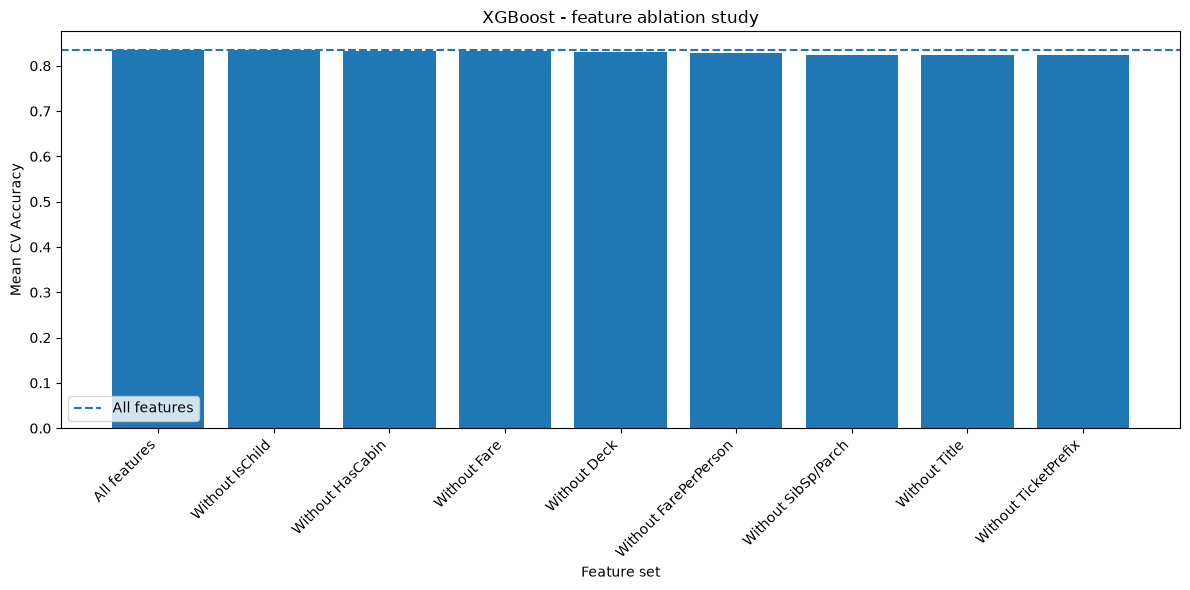

In [45]:
plt.figure(figsize=(12, 6))

plt.bar(
    xgb_feature_results_df["Feature set"],
    xgb_feature_results_df["CV Accuracy"],
)

plt.axhline(
    y=xgb_feature_results_df.loc[
        xgb_feature_results_df["Feature set"] == "All features",
        "CV Accuracy"
    ].iloc[0],
    linestyle="--",
    label="All features",
)

plt.ylabel("Mean CV Accuracy")
plt.xlabel("Feature set")
plt.title("XGBoost - feature ablation study")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

jednak mniejsza liczba cech wcale nie pomaga

a moze kombinacja mniej cech + inne hiperparametry pomoze?

In [46]:
candidate_feature_sets = {
    "All features": X_train.columns.tolist(),

    "Without IsChild": [
        col for col in X_train.columns
        if col != "IsChild"
    ],

    "Without HasCabin": [
        col for col in X_train.columns
        if col != "HasCabin"
    ],

    "Without Deck": [
        col for col in X_train.columns
        if not col.startswith("Deck_")
    ],

    "Without IsChild + HasCabin": [
        col for col in X_train.columns
        if col not in ["IsChild", "HasCabin"]
    ],

    "Without IsChild + Deck": [
        col for col in X_train.columns
        if col != "IsChild"
        and not col.startswith("Deck_")
    ],
}

In [47]:
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

In [48]:
feature_tuning_results = []

for feature_set_name, features in candidate_feature_sets.items():

    grid = GridSearchCV(
        estimator=RandomForestClassifier(
            random_state=RANDOM_STATE
        ),
        param_grid=rf_param_grid,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
        refit="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )

    grid.fit(
        X_train[features],
        y_train
    )

    best_index = grid.best_index_

    feature_tuning_results.append({
        "Feature set": feature_set_name,
        "Number of features": len(features),

        "Best CV Accuracy":
            grid.cv_results_["mean_test_accuracy"][best_index],

        "STD Accuracy":
            grid.cv_results_["std_test_accuracy"][best_index],

        "Best CV F1":
            grid.cv_results_["mean_test_f1"][best_index],

        "STD F1":
            grid.cv_results_["std_test_f1"][best_index],

        "Mean Train Accuracy":
            grid.cv_results_["mean_train_accuracy"][best_index],

        "Best parameters":
            grid.best_params_,
    })

In [49]:
feature_tuning_df = pd.DataFrame(feature_tuning_results)

feature_tuning_df = feature_tuning_df.sort_values(
    "Best CV Accuracy",
    ascending=False,
)

feature_tuning_df

,Feature set,Number of features,Best CV Accuracy,STD Accuracy,Best CV F1,STD F1,Mean Train Accuracy,Best parameters
3,Without Deck,24,0.848390,0.030876,0.791953,0.044166,0.958570,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
5,Without IsChild + Deck,23,0.846981,0.033309,0.789111,0.049118,0.956463,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
0,All features,32,0.842746,0.016483,0.791793,0.022184,0.993679,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
4,Without IsChild + HasCabin,30,0.841347,0.020651,0.785161,0.024368,0.934343,"{'max_depth': 8, 'min_samples_leaf': 1, 'min_s..."
2,Without HasCabin,31,0.841338,0.022115,0.784016,0.029548,0.929778,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
1,Without IsChild,31,0.841328,0.011753,0.789333,0.018386,0.993679,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


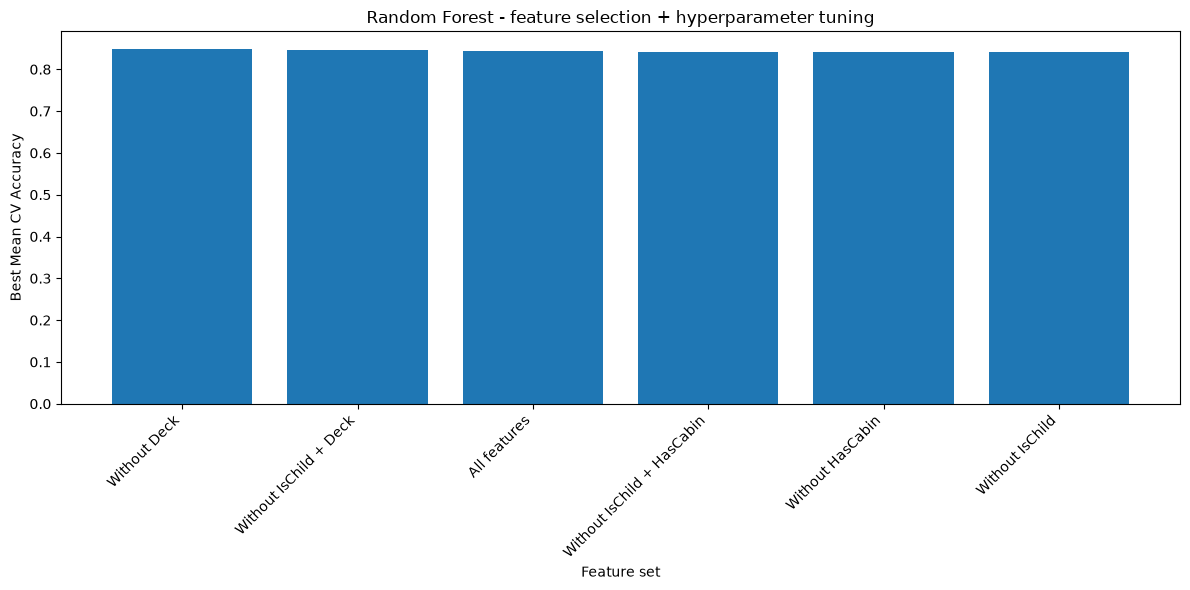

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(
    feature_tuning_df["Feature set"],
    feature_tuning_df["Best CV Accuracy"],
)

plt.ylabel("Best Mean CV Accuracy")
plt.xlabel("Feature set")
plt.title(
    "Random Forest - feature selection + hyperparameter tuning"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [51]:
best_without_deck = feature_tuning_df[
    feature_tuning_df["Feature set"] == "Without Deck"
]

print(best_without_deck["Best parameters"].iloc[0])

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


without deck okazał się być trochę lepszy dla randomforestu. Sprawdźmy dla XGBoosta

In [52]:
xgb_param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [100, 150, 200, 300],
}

xgb_feature_tuning_results = []

for feature_set_name, features in candidate_feature_sets.items():

    grid = GridSearchCV(
        estimator=XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
        ),
        param_grid=xgb_param_grid,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
        refit="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )

    grid.fit(
        X_train[features],
        y_train
    )

    best_index = grid.best_index_

    xgb_feature_tuning_results.append({
        "Feature set": feature_set_name,
        "Number of features": len(features),

        "Best CV Accuracy":
            grid.cv_results_["mean_test_accuracy"][best_index],

        "STD Accuracy":
            grid.cv_results_["std_test_accuracy"][best_index],

        "Best CV F1":
            grid.cv_results_["mean_test_f1"][best_index],

        "STD F1":
            grid.cv_results_["std_test_f1"][best_index],

        "Mean Train Accuracy":
            grid.cv_results_["mean_train_accuracy"][best_index],

        "Best parameters":
            grid.best_params_,
    })

In [53]:
xgb_feature_tuning_df = pd.DataFrame(
    xgb_feature_tuning_results
)

xgb_feature_tuning_df["Train-CV Gap"] = (
    xgb_feature_tuning_df["Mean Train Accuracy"]
    - xgb_feature_tuning_df["Best CV Accuracy"]
)

xgb_feature_tuning_df = xgb_feature_tuning_df.sort_values(
    "Best CV Accuracy",
    ascending=False,
)

xgb_feature_tuning_df

,Feature set,Number of features,Best CV Accuracy,STD Accuracy,Best CV F1,STD F1,Mean Train Accuracy,Best parameters,Train-CV Gap
0,All features,32,0.834315,0.025788,0.775889,0.033435,0.943121,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.108806
1,Without IsChild,31,0.834315,0.025788,0.775889,0.033435,0.943121,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.108806
2,Without HasCabin,31,0.832946,0.030094,0.774446,0.039252,0.932236,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.099290
4,Without IsChild + HasCabin,30,0.832946,0.030094,0.774446,0.039252,0.932236,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.099290
3,Without Deck,24,0.832907,0.023775,0.774467,0.029015,0.927672,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.094765
5,Without IsChild + Deck,23,0.832907,0.023775,0.774467,0.029015,0.927672,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.094765


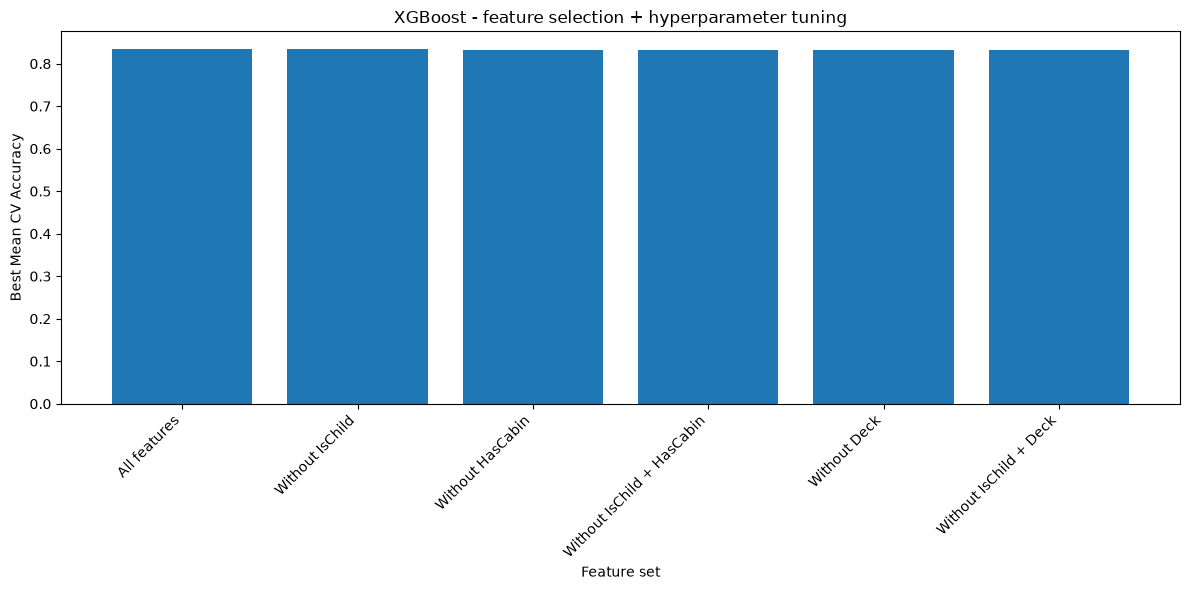

In [54]:
plt.figure(figsize=(12, 6))

plt.bar(
    xgb_feature_tuning_df["Feature set"],
    xgb_feature_tuning_df["Best CV Accuracy"],
)

plt.ylabel("Best Mean CV Accuracy")
plt.xlabel("Feature set")
plt.title(
    "XGBoost - feature selection + hyperparameter tuning"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dla XGBoosta nic nie zmienia, ale znaleźliśmy lepszego RandomForesta

In [55]:
best_rf_without_deck = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=300,
    random_state=RANDOM_STATE,
)

rf_without_deck_features = [
    col for col in X_train.columns
    if not col.startswith("Deck_")
]

best_rf_without_deck.fit(
    X_train[rf_without_deck_features],
    y_train,
)

best_rf_without_deck_scores = evaluate_model(
    best_rf_without_deck,
    X_train[rf_without_deck_features],
    X_test[rf_without_deck_features],
    y_train,
    y_test,
)

TRAIN
Accuracy: 0.9241573033707865
F1: 0.896551724137931

TEST
Accuracy: 0.7932960893854749
F1: 0.7218045112781954


PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI

           Model  Train Accuracy  Test Accuracy  Train F1  Test F1
Dummy Classifier        0.616573       0.614525  0.000000 0.000000
   Random Forest        0.924157       0.793296  0.896552 0.721805
         XGBoost        0.935393       0.821229  0.912879 0.761194


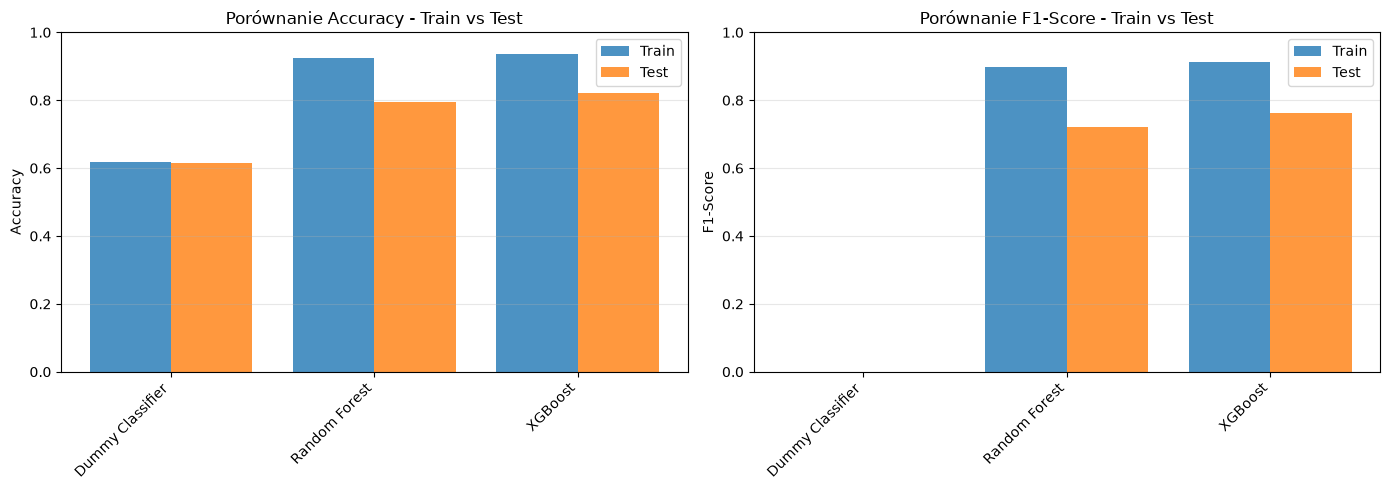

In [56]:
model_scores = {
    "Dummy Classifier": dummy_scores,
    "Random Forest": best_rf_without_deck_scores,
    "XGBoost": best_xgb_scores,
}

comparison_df = pd.DataFrame([
    {"Model": model_name, **scores}
    for model_name, scores in model_scores.items()
])

print("=" * 80)
print("PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI")
print("=" * 80)
print("\n" + comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = range(len(comparison_df))

axes[0].bar(
    [i - 0.2 for i in x_pos],
    comparison_df["Train Accuracy"],
    width=0.4,
    label="Train",
    alpha=0.8
)

axes[0].bar(
    [i + 0.2 for i in x_pos],
    comparison_df["Test Accuracy"],
    width=0.4,
    label="Test",
    alpha=0.8
)

axes[0].set_ylabel("Accuracy")
axes[0].set_title("Porównanie Accuracy - Train vs Test")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(
    comparison_df["Model"],
    rotation=45,
    ha="right"
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].bar(
    [i - 0.2 for i in x_pos],
    comparison_df["Train F1"],
    width=0.4,
    label="Train",
    alpha=0.8
)

axes[1].bar(
    [i + 0.2 for i in x_pos],
    comparison_df["Test F1"],
    width=0.4,
    label="Test",
    alpha=0.8
)

axes[1].set_ylabel("F1-Score")
axes[1].set_title("Porównanie F1-Score - Train vs Test")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    comparison_df["Model"],
    rotation=45,
    ha="right"
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

kurczę, ale ja chcę poprawiać XGBoosta, bo to on ma tu lepsze wyniki na danych testowych

xgboost, ma dodatkowe hiperparametry, Sprawdźmy je

In [57]:
BASE_XGB_PARAMS = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 200,
    "random_state": RANDOM_STATE,
    "eval_metric": "logloss",
}

stwórzmy funkcję która ustandaryzuje te testy:

In [58]:
def test_xgb_parameter(
    parameter_name,
    parameter_values,
    base_params,
    X_train,
    y_train,
    cv
):
    results = []

    for value in parameter_values:
        params = base_params.copy()
        params[parameter_name] = value

        model = XGBClassifier(**params)

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "accuracy": "accuracy",
                "f1": "f1",
            },
            return_train_score=True,
        )

        results.append({
            parameter_name: value,
            "Mean Train Accuracy": scores["train_accuracy"].mean(),
            "Mean CV Accuracy": scores["test_accuracy"].mean(),
            "STD CV Accuracy": scores["test_accuracy"].std(),
            "Mean Train F1": scores["train_f1"].mean(),
            "Mean CV F1": scores["test_f1"].mean(),
            "STD CV F1": scores["test_f1"].std(),
        })

    results_df = pd.DataFrame(results)

    print(
        results_df.sort_values(
            "Mean CV Accuracy",
            ascending=False
        ).to_string(index=False)
    )

    best_row = results_df.loc[
        results_df["Mean CV Accuracy"].idxmax()
    ]

    print("\nBest value:")
    print(parameter_name, "=", best_row[parameter_name])

    print(
        "Best CV Accuracy:",
        best_row["Mean CV Accuracy"]
    )

    print(
        "Best CV F1:",
        best_row["Mean CV F1"]
    )

    return results_df

funkcja do wykresów:

In [59]:
def plot_xgb_parameter_results(
    results_df,
    parameter_name
):
    plt.figure(figsize=(10, 5))

    plt.plot(
        results_df[parameter_name],
        results_df["Mean CV Accuracy"],
        marker="o",
        label="CV Accuracy",
    )

    plt.plot(
        results_df[parameter_name],
        results_df["Mean CV F1"],
        marker="o",
        label="CV F1",
    )

    plt.xlabel(parameter_name)
    plt.ylabel("Mean CV score")
    plt.title(
        f"XGBoost - wpływ {parameter_name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))

    plt.plot(
        results_df[parameter_name],
        results_df["Mean Train Accuracy"],
        marker="o",
        label="Train Accuracy",
    )

    plt.plot(
        results_df[parameter_name],
        results_df["Mean CV Accuracy"],
        marker="o",
        label="CV Accuracy",
    )

    plt.xlabel(parameter_name)
    plt.ylabel("Accuracy")
    plt.title(
        f"XGBoost - Train vs CV dla {parameter_name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

1. subsample

 subsample  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
       1.0             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
       0.9             0.948038          0.828711         0.023254       0.930291    0.768087   0.031038
       0.6             0.943120          0.827302         0.022010       0.923813    0.763131   0.029796
       0.7             0.945930          0.821678         0.020156       0.927571    0.756320   0.027249
       0.5             0.937150          0.818891         0.026622       0.915757    0.752908   0.032567
       0.8             0.946984          0.817473         0.019287       0.928865    0.752052   0.025516

Best value:
subsample = 1.0
Best CV Accuracy: 0.8343149807938539
Best CV F1: 0.7758892433819374


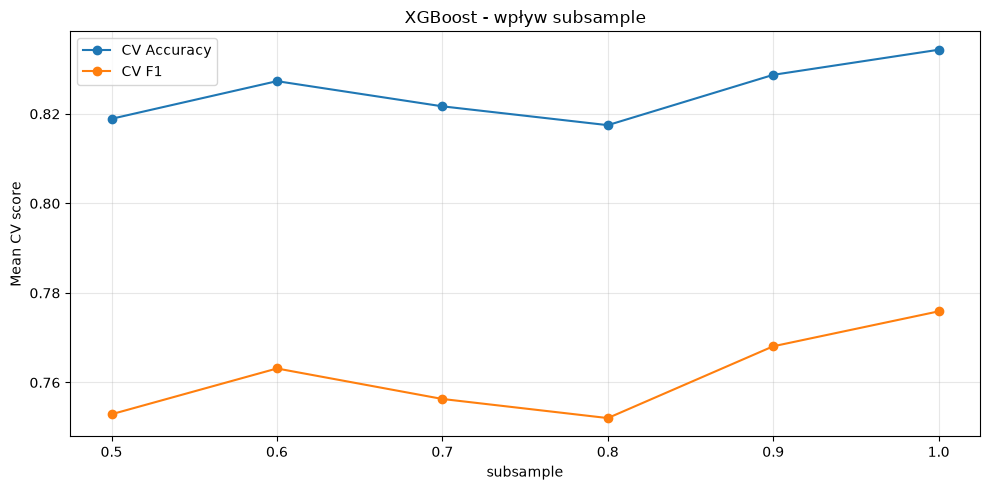

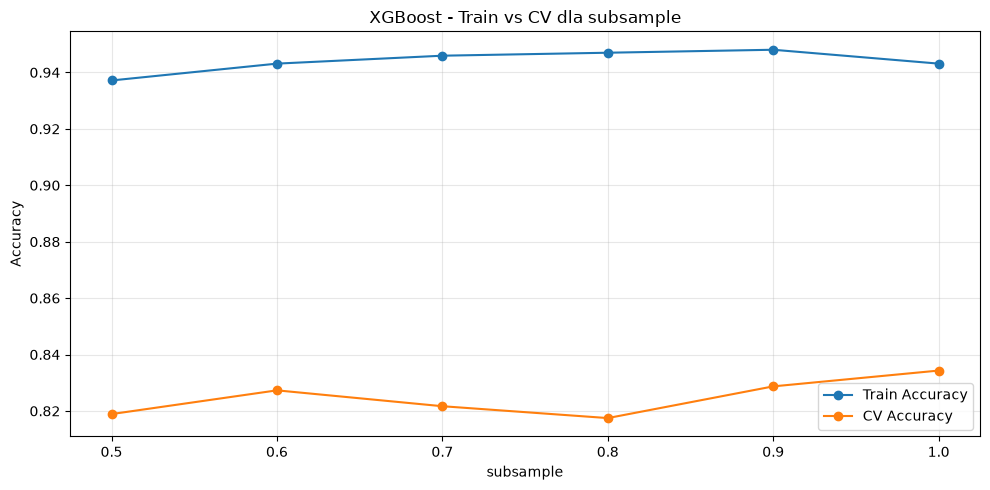

In [60]:
subsample_values = [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
]

subsample_results_df = test_xgb_parameter(
    parameter_name="subsample",
    parameter_values=subsample_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    subsample_results_df,
    "subsample"
)

domyślne subsample wygrało

2. colsample_bytree

 colsample_bytree  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
              1.0             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
              0.6             0.938909          0.830099         0.020157       0.917555    0.770502   0.026156
              0.9             0.943123          0.828711         0.025686       0.923182    0.766692   0.031971
              0.8             0.943123          0.825884         0.025728       0.923078    0.764928   0.029452
              0.5             0.936800          0.825874         0.023016       0.914658    0.765379   0.028838
              0.7             0.942068          0.823067         0.024239       0.921728    0.761789   0.029200

Best value:
colsample_bytree = 1.0
Best CV Accuracy: 0.8343149807938539
Best CV F1: 0.7758892433819374


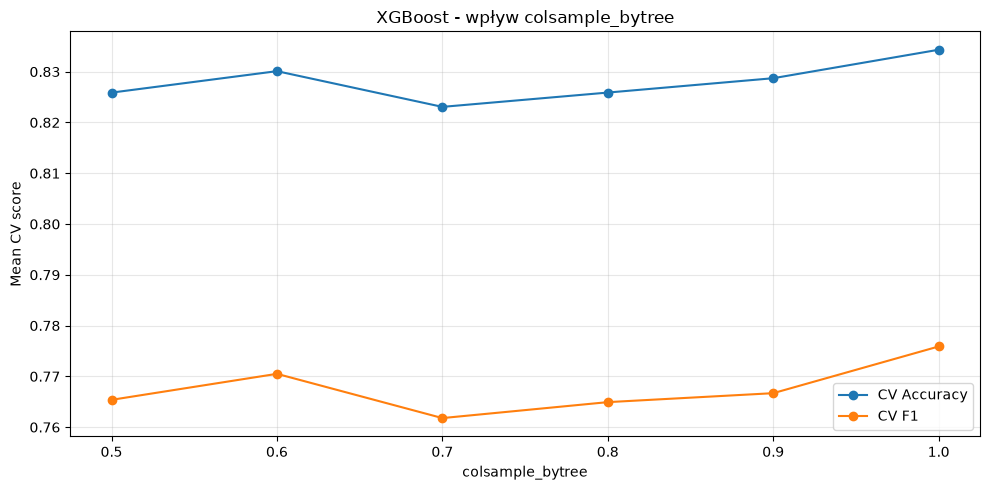

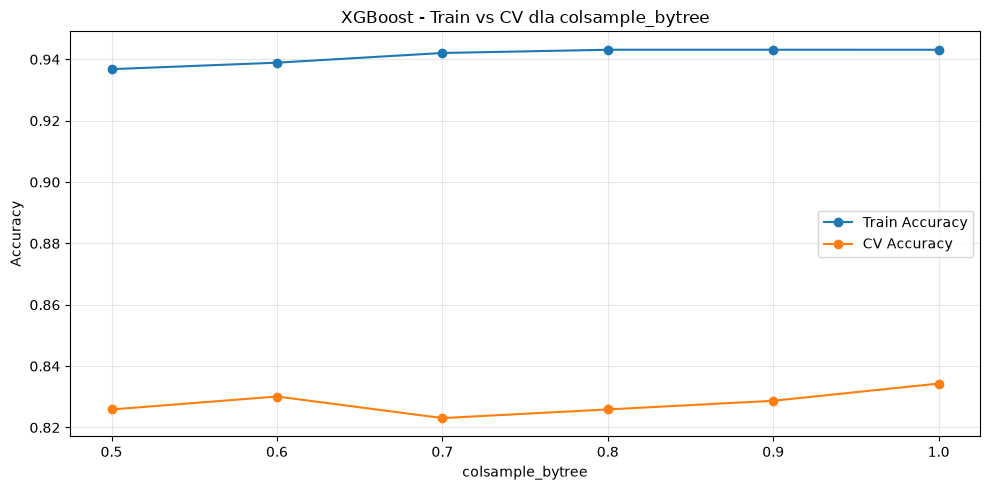

In [61]:
colsample_values = [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
]

colsample_results_df = test_xgb_parameter(
    parameter_name="colsample_bytree",
    parameter_values=colsample_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    colsample_results_df,
    "colsample_bytree"
)

domyślne colsample_bytree tez wygrało

3. min_child_weight

 min_child_weight  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
                1             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
                3             0.918892          0.820299         0.035588       0.889375    0.759450   0.043087
                2             0.928726          0.820290         0.029552       0.902960    0.754538   0.035821
                5             0.905903          0.818891         0.035017       0.870813    0.756317   0.041658
               15             0.849369          0.816025         0.018952       0.787620    0.743020   0.020526
                8             0.885191          0.814626         0.017924       0.841640    0.748517   0.014959
               10             0.879219          0.809032         0.022021       0.832637    0.740535   0.026387

Best value:
min_child_weight = 1.0
Best CV Accuracy: 0.8343149807938539
Best CV F1: 0.7758892433819374


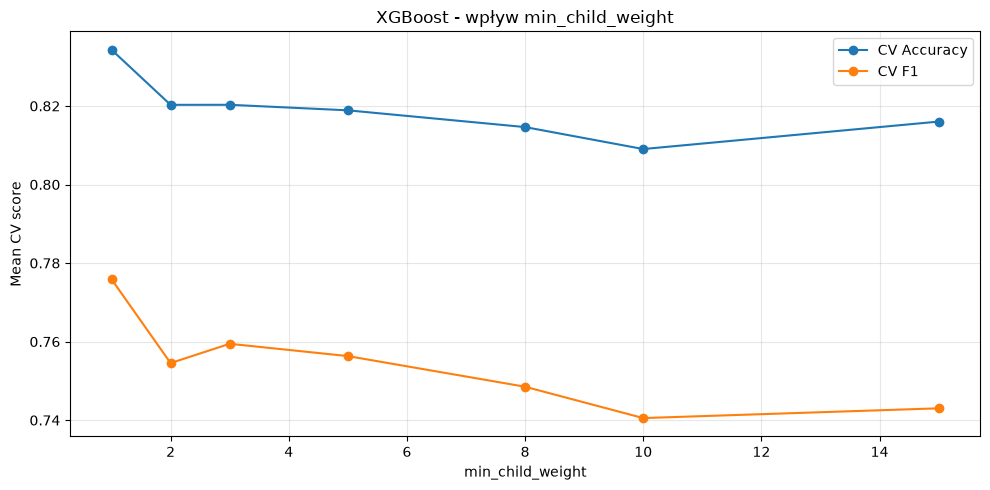

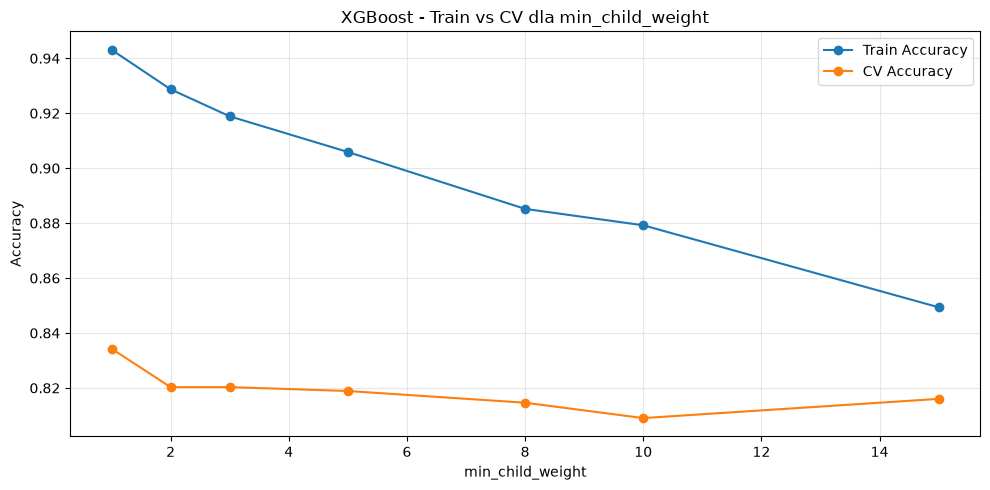

In [62]:
min_child_weight_values = [
    1,
    2,
    3,
    5,
    8,
    10,
    15,
]

min_child_weight_results_df = test_xgb_parameter(
    parameter_name="min_child_weight",
    parameter_values=min_child_weight_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    min_child_weight_results_df,
    "min_child_weight"
)

domyślne min_child_weight=1 tez wygrało

4. Gamma

 gamma  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
  0.05             0.944876          0.835743         0.029219       0.925713    0.778396   0.037285
  0.00             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
  0.10             0.943120          0.831518         0.026635       0.923311    0.771320   0.034092
  0.01             0.945578          0.825914         0.032015       0.926625    0.764478   0.042651
  0.25             0.933993          0.825904         0.030190       0.910168    0.762956   0.038281
  0.50             0.919949          0.825904         0.031121       0.890789    0.763999   0.038401
  1.00             0.903094          0.816045         0.033394       0.866349    0.746820   0.044545
  2.00             0.889749          0.814636         0.023472       0.847027    0.741834   0.034621

Best value:
gamma = 0.05
Best CV Accuracy: 0.8357431301093273
Best CV F1: 0.77839594404740

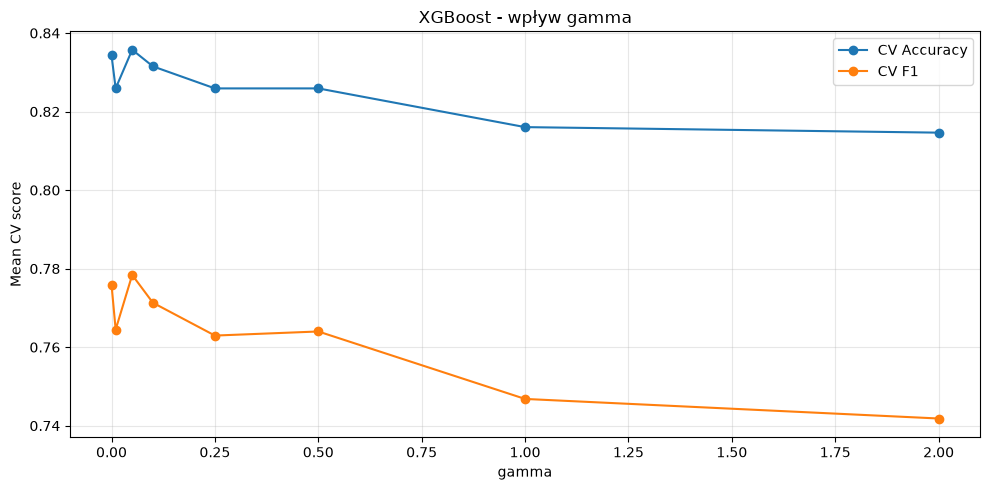

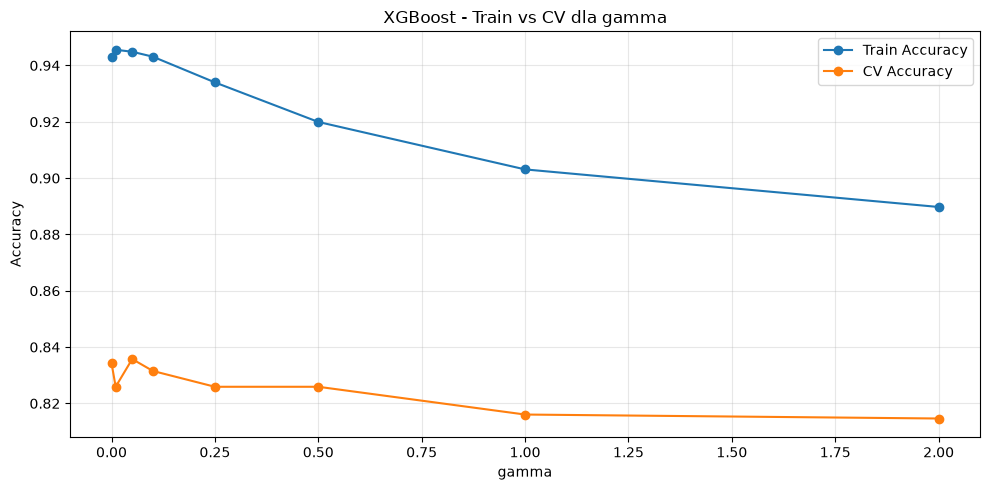

In [63]:
gamma_values = [
    0,
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    1,
    2,
]

gamma_results_df = test_xgb_parameter(
    parameter_name="gamma",
    parameter_values=gamma_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    gamma_results_df,
    "gamma"
)

uuu inna gamma okazuje się być lepsza : gamma=0.05

5. reg_alpha

 reg_alpha  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
     0.000             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
     0.050             0.943822          0.831498         0.024826       0.924198    0.770619   0.029583
     0.500             0.941013          0.828721         0.031174       0.920720    0.764892   0.040060
     0.010             0.943122          0.828701         0.026506       0.923134    0.767637   0.032541
     0.001             0.943824          0.827292         0.022086       0.924276    0.766228   0.025355
     1.000             0.933991          0.825884         0.031294       0.910676    0.763994   0.038044
     0.100             0.941715          0.824495         0.026955       0.921387    0.760498   0.034168
     2.000             0.914332          0.823077         0.026859       0.883313    0.757266   0.033040
     5.000             0.882374          0.820240      

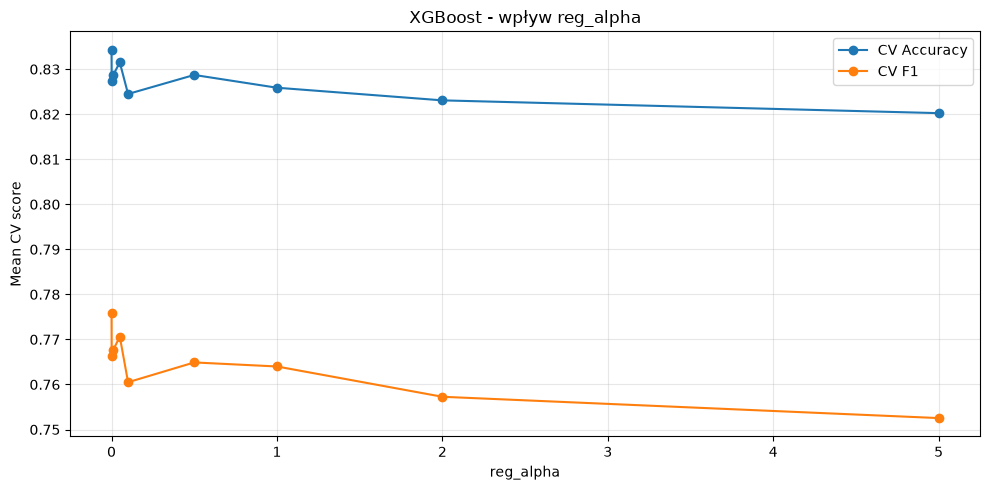

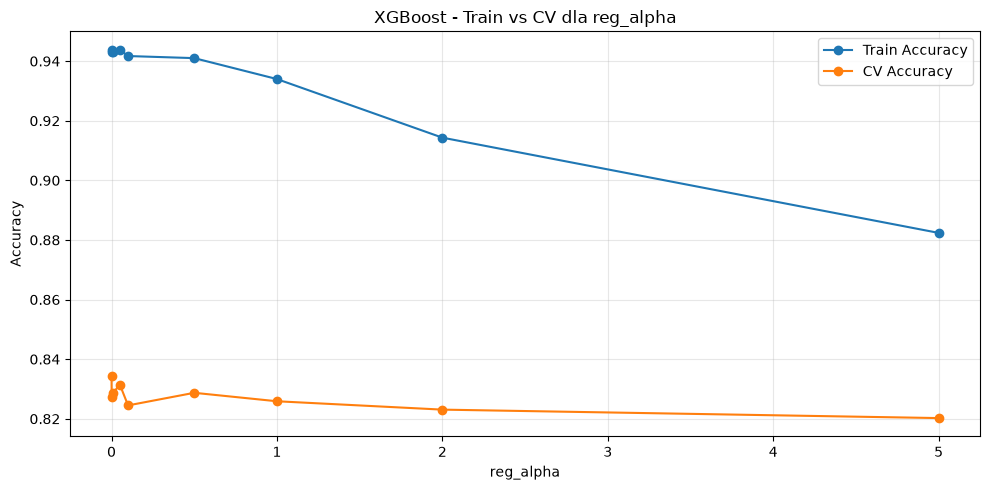

In [64]:
reg_alpha_values = [
    0,
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
    1,
    2,
    5,
]

reg_alpha_results_df = test_xgb_parameter(
    parameter_name="reg_alpha",
    parameter_values=reg_alpha_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    reg_alpha_results_df,
    "reg_alpha"
)

reg_alpha=0 domyślne tez wygrało

6. reg_lambda

 reg_lambda  Mean Train Accuracy  Mean CV Accuracy  STD CV Accuracy  Mean Train F1  Mean CV F1  STD CV F1
        1.0             0.943121          0.834315         0.025788       0.923328    0.775889   0.033435
        0.0             0.952253          0.828721         0.032076       0.935628    0.766997   0.039227
        0.5             0.946985          0.828711         0.024092       0.928499    0.768374   0.030073
        5.0             0.928373          0.828701         0.029974       0.903169    0.764659   0.040221
        0.1             0.950142          0.827302         0.021554       0.932874    0.765297   0.024474
        2.0             0.938204          0.827302         0.029952       0.916562    0.765289   0.037346
       10.0             0.914681          0.813247         0.026882       0.884011    0.745194   0.032714
       20.0             0.905552          0.813247         0.029351       0.870318    0.745404   0.034709

Best value:
reg_lambda = 1.0
Best CV Accuracy

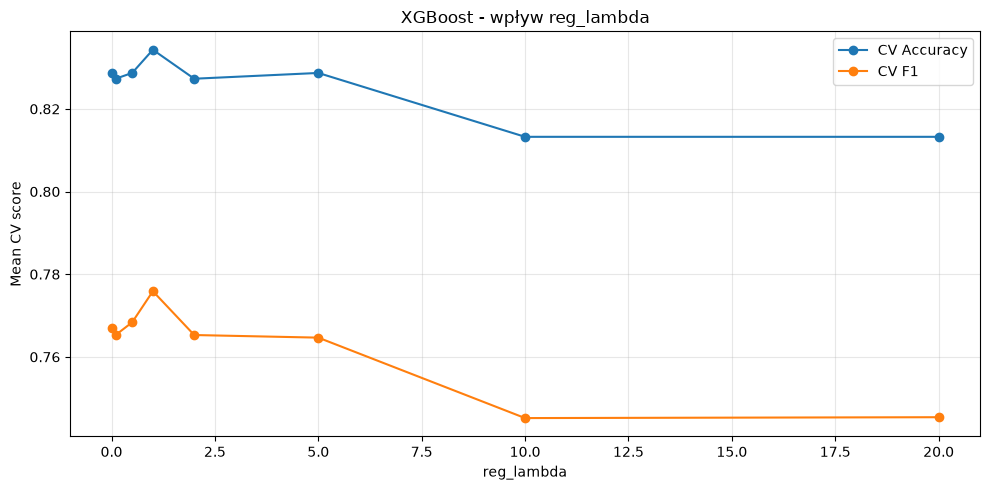

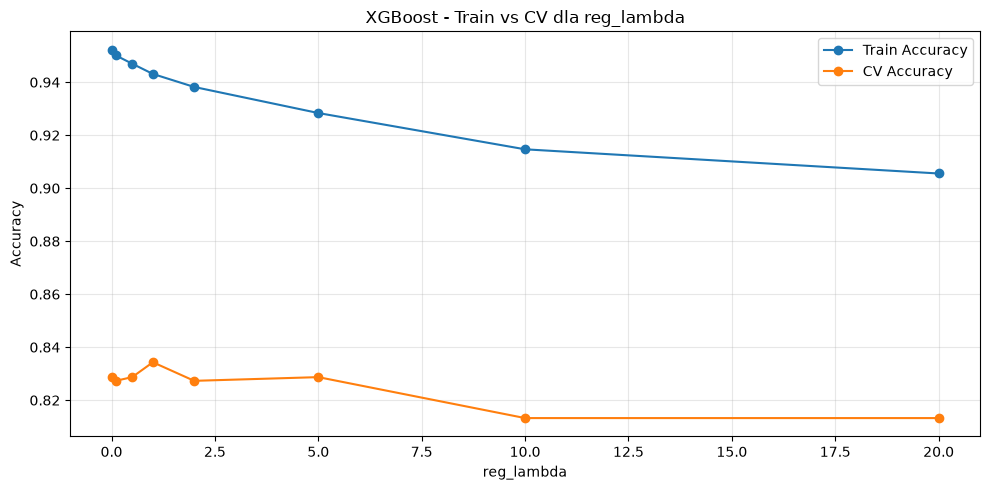

In [65]:
reg_lambda_values = [
    0,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
]

reg_lambda_results_df = test_xgb_parameter(
    parameter_name="reg_lambda",
    parameter_values=reg_lambda_values,
    base_params=BASE_XGB_PARAMS,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
)

plot_xgb_parameter_results(
    reg_lambda_results_df,
    "reg_lambda"
)

domyślne reg_lambda=1 tez wygrało

skoro gamma okazała się być jedynym sensownym hiperparametrem który daje lepszy wynik, zróbmy teraz gridsearch z nią

In [67]:
final_xgb_param_grid = {
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "n_estimators": [150, 200, 250, 300],
    "gamma": [0, 0.025, 0.05, 0.075, 0.1],
}

final_xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        subsample=1.0,
        colsample_bytree=1.0,
        min_child_weight=1,
        reg_alpha=0,
        reg_lambda=1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    ),
    param_grid=final_xgb_param_grid,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1",
    },
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

final_xgb_grid.fit(X_train, y_train)

final_xgb_results = pd.DataFrame(
    final_xgb_grid.cv_results_
)

final_xgb_results[[
    "param_max_depth",
    "param_learning_rate",
    "param_n_estimators",
    "param_gamma",
    "mean_train_accuracy",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_train_f1",
    "mean_test_f1",
    "std_test_f1",
]].sort_values(
    "mean_test_accuracy",
    ascending=False,
).head(15)

,param_max_depth,param_learning_rate,param_n_estimators,param_gamma,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_f1,mean_test_f1,std_test_f1
220,5,0.07,150,0.100,0.944875,0.838530,0.022728,0.925656,0.782255,0.027322
115,5,0.05,300,0.050,0.953655,0.837161,0.032573,0.937764,0.779614,0.043482
114,5,0.05,250,0.050,0.948038,0.837152,0.028437,0.930179,0.780472,0.037232
113,5,0.05,200,0.050,0.944876,0.835743,0.029219,0.925713,0.778396,0.037285
67,5,0.05,300,0.025,0.953303,0.835723,0.023798,0.937307,0.779270,0.028816
223,5,0.07,300,0.100,0.949790,0.834325,0.021572,0.932377,0.779348,0.026440
221,5,0.07,200,0.100,0.949088,0.834325,0.021572,0.931357,0.779348,0.026440
222,5,0.07,250,0.100,0.949790,0.834325,0.021572,0.932377,0.779348,0.026440
150,5,0.03,250,0.075,0.937151,0.834325,0.026113,0.914848,0.775281,0.031921
65,5,0.05,200,0.025,0.943823,0.834325,0.024948,0.924276,0.774125,0.032846


mamy nowego najlepszego xgboosta!

- max_depth = 5
- learning_rate = 0.07
- n_estimators = 150
- gamma = 0.1

In [68]:
best_xgb = XGBClassifier(
    max_depth=5,
    learning_rate=0.07,
    n_estimators=150,
    gamma=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=1,
    reg_alpha=0,
    reg_lambda=1,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

best_xgb.fit(X_train, y_train)

best_xgb_scores = evaluate_model(
    best_xgb,
    X_train,
    X_test,
    y_train,
    y_test,
)

TRAIN
Accuracy: 0.9424157303370787
F1: 0.9227871939736346

TEST
Accuracy: 0.8044692737430168
F1: 0.7407407407407407


In [69]:
dummy_cv_accuracy = cross_val_score(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
).mean()

rf_cv_accuracy = 0.848390

xgb_cv_accuracy = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
).mean()

In [70]:
rf_cv_accuracy = cross_val_score(
    best_rf_without_deck,
    X_train[rf_without_deck_features],
    y_train,
    cv=cv,
    scoring="accuracy",
).mean()

In [71]:
model_scores = {
    "Dummy Classifier": {
        **dummy_scores,
        "CV Accuracy": dummy_cv_accuracy,
    },

    "Random Forest": {
        **best_rf_without_deck_scores,
        "CV Accuracy": rf_cv_accuracy,
    },

    "XGBoost": {
        **best_xgb_scores,
        "CV Accuracy": xgb_cv_accuracy,
    },
}

comparison_df = pd.DataFrame([
    {"Model": model_name, **scores}
    for model_name, scores in model_scores.items()
])

print("=" * 80)
print("PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI")
print("=" * 80)
print("\n" + comparison_df.to_string(index=False))

PODSUMOWANIE WYNIKÓW - PORÓWNANIE MODELI

           Model  Train Accuracy  Test Accuracy  Train F1  Test F1  CV Accuracy
Dummy Classifier        0.616573       0.614525  0.000000 0.000000     0.616576
   Random Forest        0.924157       0.793296  0.896552 0.721805     0.835723
         XGBoost        0.942416       0.804469  0.922787 0.740741     0.838530


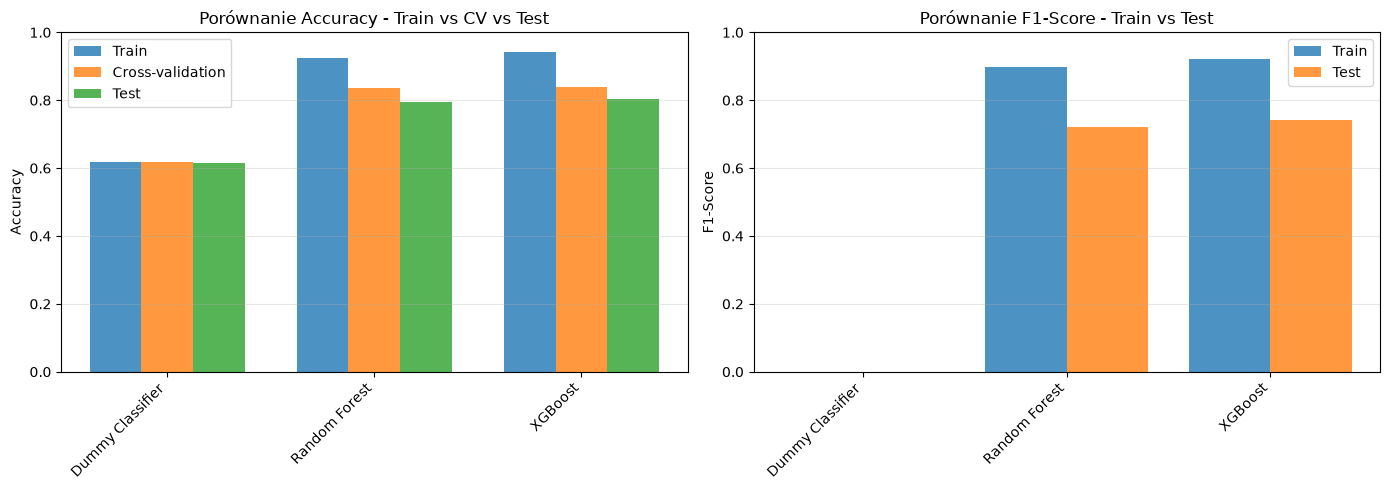

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = range(len(comparison_df))
width = 0.25

axes[0].bar(
    [i - width for i in x_pos],
    comparison_df["Train Accuracy"],
    width=width,
    label="Train",
    alpha=0.8
)

axes[0].bar(
    x_pos,
    comparison_df["CV Accuracy"],
    width=width,
    label="Cross-validation",
    alpha=0.8
)

axes[0].bar(
    [i + width for i in x_pos],
    comparison_df["Test Accuracy"],
    width=width,
    label="Test",
    alpha=0.8
)

axes[0].set_ylabel("Accuracy")
axes[0].set_title("Porównanie Accuracy - Train vs CV vs Test")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(
    comparison_df["Model"],
    rotation=45,
    ha="right"
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].bar(
    [i - 0.2 for i in x_pos],
    comparison_df["Train F1"],
    width=0.4,
    label="Train",
    alpha=0.8
)

axes[1].bar(
    [i + 0.2 for i in x_pos],
    comparison_df["Test F1"],
    width=0.4,
    label="Test",
    alpha=0.8
)

axes[1].set_ylabel("F1-Score")
axes[1].set_title("Porównanie F1-Score - Train vs Test")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    comparison_df["Model"],
    rotation=45,
    ha="right"
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

Mógłbym dalej dostrajać XGBoosta, kolejnymi hiperparametrami, lub feature engineering, ale nie byłoby to juz takie efektywne. Nie mam juz tez czasu.

najlepszy model według cross validation accuracy jaki mi się udało wytrenować to powyzszy xgboost, z wartością 0.838530

z perspektywy zakończonego notebooka zdaję sobie sprawę, ze moje podejście tutaj było bardzo chaotyczne - realizowanie przypadkowych pomysłów na polepszenie moich modeli - zamiast egzekwowanie jakiegoś planu, np sprawdzania najpierw modeli z róznymi features, potem strojenia hiperparametrów itd. Równiez mój kod jest mało czytelny - mogłem na samym początku stworzyć jakiś template który wyświetlałby wyniki, tabele itp. w podobny sposób. Powinienem równiez w wynikach modeli bardziej brać pod uwagę standart deviation wyników, jak i równiez lepiej na samym początku projektu zdefiniować metryki według których będę oceniać modele. Drugi raz, całkiem inaczej przeprowadziłbym ten notebook, więc widzę ze wiele się nauczyłem.